In [15]:
import jax
from jax import lax, Array
import jax.numpy as jnp
from jax.scipy.linalg import expm
jax.config.update('jax_enable_x64', False)
import numpy as np
from numpy.linalg import matrix_power
from scipy.stats import entropy, poisson
from scipy.optimize import minimize
from scipy.special import softmax, logsumexp
from itertools import product as iproduct
from time import perf_counter
from functools import partial

import os, sys, pathlib
os.environ["OPENBLAS_NUM_THREADS"] = "1"
_project_root = pathlib.Path.cwd().resolve()
sys.path.insert(0, str(_project_root.parents[0]))
from utils import H, Hv, KL, KLv, get_traj
import ising
from ising import (
  propagate_ctmc, EP_cost,
  precompute_ep, make_uniformization_coeffs, pmmc_kernel_fast, pmmc_kernel_old,
  find_optimal_prior, build_system_from_graph, precompute_ep_jax, apply_G
)

GraphT = tuple[Array, Array, Array]

### MPL Config

In [ ]:
import shutil, matplotlib as mpl
print(shutil.which("latex"))
print(shutil.which("kpsewhich"))
print(mpl.get_configdir())
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.axes import Axes
from config import __mpl_paper_params__
mpl.rcParams.update(__mpl_paper_params__)

/Library/TeX/texbin/latex
/Library/TeX/texbin/kpsewhich
/Users/jakeschaefer/.matplotlib


### Ising Model

### Experiments

In [69]:
# ── Parameters ──────────────────────────────
# L      = 3
# shape  = (L, L)
N      = 25
n_states = 1 << N

J      = 0.2
h      = 0.0
T1, T2 = 1/3.0, 1/1.0
betas_nu = jnp.array([1/T1, 1/T2])
gammas_nu = jnp.array([1.0, 1.0])
dt = 1e-3

# speed limit eps
eps = 0.05
w1_num_points = 200  # logarithmically spaced time points

N_max = 20_000

In [ ]:
# graph = ising.make_interaction_graph(shape)
graph = ising.make_mean_field_graph(N)

# ── Initial condition ─────────────────────────────────────────────────────────
# delta function — all spins up (larger KL, more interesting dynamics)
all_up_idx = (1 << N) - 1
p0 = jnp.zeros(n_states)
p0 = p0.at[all_up_idx].set(1.0)
# p0 = jnp.ones((1 << N)) / (1 << N)

### Reduced

In [70]:
P0_reduced = jnp.zeros(N + 1, dtype=jnp.float32)
P0_reduced = P0_reduced.at[N].set(1.0)

Permutation symmetry -> `make_mean_field_graph(N)` treats every spin identically. The energy change for flipping a spin depends only on:
- whether that spin is up or down
- the total magnetization
- the common params $J, h,\beta_\nu,\gamma_\nu$

It does not depend on the spin's label

In [ ]:

rows, rates, rates_nu, escape, g, lam, w, d = ising.setup_uniformization(
  graph, J, h, betas_nu, gammas_nu, dt,
)
# rates = rates_nu.sum(axis=0)

print("lambda =", lam)
print("uniformization terms per dt =", len(w))

print("Computing trajectory...")

pN, pts, heat_steps, activity_steps = ising.get_uniformized_traj(
  p0, rows, rates, g, lam, w, d, N_max,
)

Ns = jnp.arange(1, N_max + 1)

lambda = 18.939833953748757
uniformization terms per dt = 6
Computing trajectory...


In [ ]:
p_avgs = jnp.cumsum(pts[:-1], axis=0) / Ns[:, None]                  # broadcasting
Gp_avgs = p_avgs + (pts[1:] - p0[None, :]) / Ns[:, None]                         # G @ p_avg for each N
entropy_diffs = Hv(pts[1:]) - H(p0)

pmmcs = entropy_diffs + Ns * (Hv(p_avgs) - Hv(Gp_avgs))

medium_ep_steps = -(heat_steps @ betas_nu)

medium_ep_curve = jnp.cumsum(medium_ep_steps)

ep_curve = entropy_diffs + medium_ep_curve

pi, pi_err, pi_iters = ising.find_stationary(rows, rates, lam)

kl = KL(p0, pi)

nonadiabatic_eps = kl - KLv(pts[1:], pi)

# total variational distance to pi
tv_to_pi = 0.5 * jnp.sum(jnp.abs(pts[:-1] - pi[None, :]), axis=1)

indices = np.where(tv_to_pi <= eps)[0]
t_mix_p0 = indices[0] * dt if len(indices) else np.inf
print(f"t_mix = {t_mix_p0}, N_mix = {t_mix_p0/dt}")

# ---- total EP, physical optimal prior calculation
g_beta = betas_nu @ g
c_1step = ising.integrated_GT(g_beta, rows, rates, lam, d)
q_phys, residual_step, info = ising.find_optimal_prior_rows_rates(rows, rates, c_1step, lam, w)

Gq_phys = ising.apply_G(q_phys, rows, rates, lam, w)
# Decomposition: Total EP = MC(q*) + N * residual_step
# so MC(q*) is the "extractable" part of EP relative to the optimal reference.
mc_steps       = KLv(pts[:-1], q_phys) - KLv(pts[1:], Gq_phys)
mc_phys        = jnp.cumsum(mc_steps)
residual_curve = Ns * residual_step

# ---- Activity / Speed limit
activity_curve = jnp.cumsum(activity_steps)

# total variation distance
dTV = 0.5 * jnp.sum(jnp.abs(pts - p0[None, :]), axis=1)

speed_limit = (2.0 * dTV[1:]) ** 2 / (2.0 * activity_curve)

ratio = dTV[1:] / activity_curve

ep_bound_exact = 2.0 * dTV[1:] * jnp.arctanh(jnp.clip(ratio, 0.0, 1.0 - 1e-12))

t_mix = 1.1300000000000001, N_mix = 1130.0


In [ ]:
import optax
from scipy.optimize import linprog
from scipy.sparse import coo_matrix
from time import perf_counter

def lipschitz_constant(f, N):
  """
  Lipschitz constant of f on the N-dimensional hypercube
  with Hamming distance.
  """
  states = jnp.arange(1 << N)
  def body(i, L):
    # flip state i
    neighbors = states ^ (1 << i)
    return jnp.maximum(L, jnp.max(jnp.abs(f - f[neighbors])))
  return lax.fori_loop(0, N, body, jnp.array(0.0))

def make_lipschitz(f, N):
  # Fix arbitrary additive constant
  f = f - f[0]
  L = lipschitz_constant(f, N)
  return f / jnp.maximum(L, 1.0)

def w1_dual_objective(f_raw, p, q, N):
  f = make_lipschitz(f_raw, N)
  return jnp.dot(f, p - q)

def w1_dual(p, q, N, n_steps=1_000, lr=1e-2):
  f = jnp.zeros_like(p)
  optimizer = optax.adam(lr)
  opt_state = optimizer.init(f)

  @jax.jit
  def step(f, opt_state):
    # Optax minimizes, so negate the dual objective
    loss, grad = jax.value_and_grad(lambda f: -w1_dual_objective(f, p, q, N))(f)
    updates, opt_state = optimizer.update(grad, opt_state, f)
    f = optax.apply_updates(f, updates)
    return f, opt_state, loss

  for _ in range(n_steps):
    f, opt_state, loss = step(f, opt_state)

  f_star = make_lipschitz(f, N)
  W1 = jnp.dot(f_star, p - q)

  return W1, f_star

def hypercube_lipschitz_constraints(N):
  M = 1 << N
  states = np.arange(M)
  srcs = []
  dsts = []

  for i in range(N):
    # include every undirected edge once
    src = states[(states & (1 << i)) == 0]
    dst = src ^ (1 << i)
    srcs.append(src)
    dsts.append(dst)

  src = np.concatenate(srcs)
  dst = np.concatenate(dsts)

  E = len(src)

  # f_src - f_dst <= 1
  # f_dst - f_src <= 1

  Es = np.arange(E)
  r = np.concatenate([Es, Es, E + Es, E + Es])
  c = np.concatenate([src, dst, src, dst])
  data = np.concatenate([np.ones(E), -np.ones(E), -np.ones(E), np.ones(E)])
  A = coo_matrix((data, (r, c)), shape=(2 * E, M)).tocsr()
  # 1-lipschitz condition
  b = np.ones(2 * E)
  return A, b

def w1_dual_exact(p, q, A_lip, b_lip):
  M = len(p)
  # scipy minimizes, whereas we want max <f,p-q>
  c = -(p - q)
  bounds = [(None, None)] * M
  # remove additive gauge freedom
  bounds[0] = (0.0, 0.0)
  result = linprog(c, A_ub=A_lip, b_ub=b_lip, bounds=bounds, method="highs")

  if not result.success:
    raise RuntimeError(result.message)

  return -result.fun, result.x


def get_speed_limit(graph: GraphT, p0: Array, pts: Array, rates_nu: Array, dt: float, N_max: int, N: int, w1_num_points: int = 200):
  rows = graph[0]
  cols = jnp.tile(jnp.arange(n_states), N).reshape(*rows.shape)
  mask_u = rows < cols
  mask_l = rows > cols

  # reverse_rates = jnp.stack([
  #   jnp.take_along_axis(rates_nu[0], rows, axis=1)[mask_u],
  #   jnp.take_along_axis(rates_nu[1], rows, axis=1)[mask_u]
  # ], axis=0)

  masked_rates = rates_nu[:, mask_u]
  # this is same as reverse_rates
  reverse_rates = rates_nu[:, mask_l]

  # ed/ge_dst = rows[mask_u]
  # edge_src = cols[mask_u]

  gather_indices_u = cols[mask_u].reshape(-1)[:, None]
  # want the probability at the destination of the forward edge, i.e. rows[mask_u], not cols[mask_l]
  gather_indices_l = cols[mask_l].reshape(-1)[:, None]

  dim_nums = lax.GatherDimensionNumbers(
    offset_dims=(), collapsed_slice_dims=(0,), start_index_map=(0,)
  )

  def mu_A(p):
    Jp = masked_rates * lax.gather(p, gather_indices_u, dim_nums, slice_sizes=(1,))[None, :]
    Jm = reverse_rates * lax.gather(p, gather_indices_l, dim_nums, slice_sizes=(1,))[None, :]
    return jnp.sum(0.5 * (Jp + Jm))

  # exactly the same
  # print(rates_nu[0][mask_l] - reverse_rates[0])
  # print(rates2[0] - rates_nu[0][mask_u])
  mu_A_vals = jax.vmap(mu_A)(pts)


  if w1_num_points >= N_max:
    sample_indices = np.arange(N_max)
  else:
    sample_indices = np.unique(
      np.rint(np.geomspace(1, N_max, num=w1_num_points)).astype(int)
    ) - 1
  Ns = jnp.asarray(sample_indices + 1)
  Ts = Ns * dt
  A_lip, b_lip = hypercube_lipschitz_constraints(N)
  w1 = jnp.array([w1_dual_exact(p0, pts[i + 1], A_lip, b_lip)[0] for i in sample_indices])

  # w1 = jax.vmap(lambda pt: w1_dual(p0, pt, N)[0])(pts[1:])

  # states = jnp.arange(n_states) #| (1 << (N+1))
  # XOR ---> metric cost matrix for wasserstein
  # D = jnp.bitwise_count(jnp.asarray(states[:, None] ^ states[None, ]))
  # print(D)

  dx_reduced = jnp.asarray(1.0)
  # dx is constant along integration axis
  # average activity over [0, T_n]
  mu_A_integrals = jnp.cumsum(mu_A_vals, axis=-1)[1:] - 0.5 * (mu_A_vals[0] + mu_A_vals[1:])
  mu_A_avgs = dx_reduced * mu_A_integrals[sample_indices] / Ns
  v1s = w1 / Ts
  ratios = jnp.clip(v1s / (2 * mu_A_avgs), 0, 1 - 1e-9)
  speed_limit_jax = 2 * w1 * jnp.arctanh(ratios)

  # print(jnp.linalg.norm(speed_limit_jax - jnp.asarray(speed_limit)) / jnp.linalg.norm(speed_limit))

  return Ts, speed_limit_jax

 



In [12]:
speed_limit_Ts, speed_limit_jax = get_speed_limit(
  graph, p0, pts, rates_nu, dt, N_max, N, w1_num_points
)

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "serif", "mathtext.fontset": "cm",
    "font.size": 9, "axes.labelsize": 9, "axes.titlesize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 7.5,
    "axes.linewidth": 0.7, "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "xtick.major.size": 3, "ytick.major.size": 3,
    "xtick.minor.size": 1.8, "ytick.minor.size": 1.8,
})

C_MC, C_MCP = '#D55E00', '#E69F00'
C_EP, C_EPNA = '#0072B2', '#56B4E9'
C_TV, C_REF = '#009E73', '#8C8C8C'

fig = plt.figure(figsize=(3.4, 3.4))          # final printed width — don't rescale in LaTeX
gs = fig.add_gridspec(2, 1, height_ratios=[3.0, 1.0], hspace=0.10,
                      left=0.17, right=0.97, top=0.95, bottom=0.24)
ax, axb = fig.add_subplot(gs[0]), None
axb = fig.add_subplot(gs[1], sharex=ax)

Ts = Ns * dt

# ── reference lines first, so data sits on top ──
ax.axhline(kl, color=C_REF, ls=':', lw=1.0, zorder=1,
           label=r'$\mathrm{D}(p_0\|\pi)$')
ax.semilogx(speed_limit_Ts, speed_limit_jax, c=C_REF, ls='--', lw=1.0,
            zorder=1, label=r'Speed limit')

# ── partners ──
ax.semilogx(Ts, nonadiabatic_eps, c=C_EPNA, lw=1.4, ls=(0, (3, 1, 1, 1)),
            zorder=3, label=r'$\Sigma_{T,\mathrm{na}}$')
ax.semilogx(Ts, mc_phys, c=C_MCP, lw=1.4, ls=(0, (5, 1.5)),
            zorder=3, label=r'$\mathcal{M}_T(q)$')

# ── heroes ──
ax.semilogx(Ts, ep_curve, c=C_EP, lw=2.2, zorder=5, label=r'$\Sigma_T$')
ax.semilogx(Ts, pmmcs,    c=C_MC, lw=2.2, zorder=5, label=r'$\mathcal{M}_T(\bar q)$')

ax.set_ylabel('Nats')
ax.set_ylim(0, 2 * pmmcs[-1])
ax.tick_params(labelbottom=False)

# parameters as an annotation, not a title — frees the top of the frame
ax.text(0.03, 0.96,
        fr'$J={J}$' '\n'
        fr'$\beta=({betas_nu[0]:.2g},{betas_nu[1]:.2g})$' '\n'
        fr'$\gamma=({gammas_nu[0]:.2g},{gammas_nu[1]:.2g})$',
        transform=ax.transAxes, va='top', ha='left', fontsize=7.5,
        linespacing=1.5)

# # mark where Sigma_T leaves the frame so the clip reads as deliberate
# i = np.argmax(ep_curve > ax.get_ylim()[1])
# if i:
#     ax.annotate('', xy=(Ts[i], ax.get_ylim()[1]), xytext=(Ts[i], ax.get_ylim()[1] * 0.88),
#                 arrowprops=dict(arrowstyle='-|>', color=C_EP, lw=1.2,
#                                 shrinkA=0, shrinkB=0), zorder=6)

# ── bottom panel: dimensionless quantity, own axis ──
axb.semilogx(Ts, tv_to_pi, c=C_TV, lw=1.6, label=r'$d_{\mathrm{TV}}(p_T,\pi)$')
axb.set(ylim=(0, 1.05), yticks=[0, 0.5, 1],
        xlim=(Ts[0], Ts[-1]), xlabel=r'Total time $T$',
        ylabel=r'$d_{\mathrm{TV}}$')

# ── legend under everything, 3 columns, no frame ──
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = axb.get_legend_handles_labels()
order = [5, 4, 3, 2, 1, 0]                     # heroes first
fig.legend([h1[k] for k in order] + h2, [l1[k] for k in order] + l2,
           loc='lower center', bbox_to_anchor=(0.57, -0.01),
           ncol=3, frameon=False, handlelength=1.9, columnspacing=1.2,
           handletextpad=0.5, labelspacing=0.35)

fig.savefig("/Users/benjmainansbacher/Downloads/pop_code/spins_ctmc.pdf",
            bbox_inches='tight', pad_inches=0.02)
plt.show()

### Comparison (Dense)

In [ ]:
N_max = 200
Ns     = jnp.arange(1, N_max + 1)

print("Building K1, K2, heat vectors g1, g2 ...")
K, g = build_system_from_graph(graph, J, h, betas_nu, gammas_nu)


print("Computing matrix exponentials (once each) ...")
# ── Propagator and time evolution ─────────────
G_dt  = expm(K * dt)

EM_dt, a_1step_nu = precompute_ep(K, g, dt)
EM_dt = jnp.asarray(EM_dt)
c_1step = betas_nu @ a_1step_nu

# ── Trajectory & Periodic MMC ──────────────────────────────────────────────────────────────────────
print("Computing trajectory ...")
pN, pts = get_traj(G_dt, p0, N_max)
p_avgs = jnp.cumsum(pts[:-1], axis=0) / Ns[:, None]                  # broadcasting
Gp_avgs = p_avgs + (pts[1:] - p0[None, :]) / Ns[:, None]                         # G @ p_avg for each N
entropy_diffs = H(pts[1:], axis=1) - H(p0)

pmmcs = entropy_diffs + Ns * (H(p_avgs, axis=1) - H(Gp_avgs, axis=1))

# ── EP curve — semigroup iteration, no extra expm calls ──────────────────────
print("Computing EP curve ...")
EM_n     = jnp.eye(n_states + 2)
heats = jnp.zeros(N_max)
for n in range(N_max):
  EM_n        = EM_n @ EM_dt
  A_n         = EM_n[:n_states, n_states:].T              # (2, ns)
  c_n         = betas_nu @ A_n               # (ns,)
  heats = heats.at[n].add(- c_n @ p0)


ep_curve = heats + entropy_diffs


print("Finding optimal prior q* ...")
q_phys, residual_step, info = find_optimal_prior(G_dt, c_1step)
print(f"  converged={info['converged']}, iterations={info['iterations']}, "
      f"KKT residual={info['kkt_residual']:.2e}, residual EP/step={residual_step:.6f}")
    
Gq_phys = G_dt @ q_phys

# Decomposition: Total EP = MC(q*) + N * residual_step
# so MC(q*) is the "extractable" part of EP relative to the optimal reference.
mc_steps       = KL(pts[:-1], q_phys, axis=1) - KL(pts[1:], Gq_phys, axis=1)
mc_phys        = jnp.cumsum(mc_steps)
residual_curve = Ns * residual_step

# verify decomposition holds
max_err = np.max(np.abs(ep_curve - mc_phys - residual_curve))
print(f"  error (should be ~0): {max_err:.2e}")

# ── Stationary state & spectral stuff ──────────────────────────────────────────────────────────
evals, vecs = np.linalg.eig(K)
order = np.argsort(np.real(evals))[::-1]
# second largest eigenval -> spectral gap
gap = - evals[order[1]]
# print(evals[order])
t_rel = 1 / gap
print("spectral gap =", gap)
print("relaxation time =", t_rel)

q_star = jnp.sum(pts[:-1], axis=0) / N_max
kl = KL(p0, q_star)
print(f"pi known (q_star): , D(p0||pi) = {kl}")

pi  = np.real(vecs[:, order[0]]) # closest to zero
pi  = np.clip(pi / pi.sum(), 0, None)
kl = KL(p0, pi)
print(f"pi solved: , D(p0||pi) = {kl}")


# \sum_x p_0(x)\log(p_0(x) / pi(x)) - p_n(x)\log(p_n(x) / pi(x))
# S(p_n) - S(p_0) + \sum_x (p_n - p_0) \log pi
nonadiabatic_eps = kl - KL(pts[1:], pi, axis=1)


In [ ]:
# then accumulate step by step alongside EM_n
EM_act_n = np.eye(n_states + 1)
speed_limit = np.zeros(N_max)
ep_bound_exact = np.zeros(N_max)
# total variation distance
dTV = 0.5 * jnp.sum(jnp.abs(pts - p0[None, :]), axis=1)
for n in range(N_max):
  EM_act_n  = EM_act_n @ EM_act_dt
  # integral_0^{(n+1)*dt} e^{Ks} lam ds
  a_n       = EM_act_n[:n_states, n_states]           
  A_n       = a_n @ p0                    # scalar, expected total activity
  # 2 * total variation distance
  speed_limit[n] = (2.0 * dTV[n+1]) ** 2 / (2 * A_n)
  ep_bound_exact[n] = (2.0 * dTV[n+1] * np.arctanh(dTV[n+1] / A_n))

In [ ]:
tv_to_pi = 0.5 * jnp.sum(jnp.abs(pts[:-1] - pi[None, :]), axis=1)
eps = 0.05
indices = np.where(tv_to_pi <= eps)[0]
if len(indices):
  t_mix_p0 = indices[0] * dt
else:
  t_mix_p0 = np.inf

print(f"{t_mix_p0=}, TV at t mix = ")
print(f"{t_mix_p0/dt}")

### Times

$$
0 = \lambda_1 > \lambda_2\geq \lambda_3\geq\cdots
$$
The spectral gap is $\gamma = -\lambda_2$. The relaxation time is
$$
t_{\text{rel}} = \frac{1}{\gamma} = \frac{1}{-\lambda_2}
$$
At late times, deviations from equilibrium generally behave like
$$
p_t - \pi \sim e^{-t/t_{\text{rel}}}v_2 = e^{\lambda_2 t} v_2,
$$
and since $\lambda_2$ is strictly negative and the smallest of such in magnitude, these will be the largest such deviations 

In [ ]:
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
ax.semilogx(Ns, pmmcs,          label=r'$\mathcal{M}_N(\bar{q})$',                    lw=2, color='maroon')
ax.semilogx(Ns, ep_curve,       label=r'Total EP',                             lw=2,   color='navy')
ax.semilogx(Ns, mc_phys,        label=r'$\mathcal{MC}_N(q)$',                 lw=2,   color='darkgreen')
# ax.semilogx(Ns, residual_curve - other)
# ax.semilogx(Ns, speed_limit, label=r'Speed limit $2\,\mathrm{TV}^2/\mathcal{A}$', lw=1.5, linestyle=':', color='red')
# ax.semilogx(Ns, ep_bound_exact, 'pink')
ax.semilogx(Ns, nonadiabatic_eps, label=r'Nonadiabatic EP', lw=2,  c='pink', alpha=1.0)
ax.semilogx(Ns, tv_to_pi)
# ax.vlines(x=np.round(time), color = 'black', linestyles='dashed', lw=1.5, ymin=0, ymax = ep_curve[-1], label=r'$\tau_{\mathrm{relax}}$', alpha=0.5)
ax.vlines(x=t_mix_p0/dt, color = 'black', linestyles='dashed', lw=1.5, ymin=0, ymax = ep_curve[-1], label=fr'$\tau_{{\mathrm{{mix}}}}(\epsilon={eps})$', alpha=0.5)
ax.text(
  x=t_mix_p0/dt, 
  y=0,                         # 0 places it at the very bottom of the axes
  s=fr"$\tau_{{\mathrm{{mix}}}}\approx {t_mix_p0/dt:.2g}\tau$",                  # Your label text
  transform=ax.get_xaxis_transform(), # Keeps x in data units, y in axes fraction (0 to 1)
  rotation=90,                 # Rotates text to match the vertical line
  verticalalignment='bottom',  # Aligns text boundary
  horizontalalignment='right', # Shifts text slightly so it does not overlap the line
  color='k'
)
ax.hlines(y=kl, xmin=Ns[0], xmax=Ns[-1], color='black', linestyles='dotted', lw=1.5, label=r'$\mathrm{D}(p_0 \| \pi)$', alpha=0.5)
ax.set_title(fr'$\tau={dt}$, $J={J}$, $\beta=({betas_nu[0]:.2g}, {betas_nu[1]:.2g})$, $\gamma=({gammas_nu[0]:.2g}, {gammas_nu[1]:.2g})$')
ax.legend(fontsize='x-small')
ax.set(xlim=(Ns[0], Ns[-1]), ylim=(0,ep_curve[-1]), xlabel=r'Total number of iterations $N$', ylabel=r'Nats')
plt.tight_layout()
plt.show()

### Plotting utils

In [61]:
def add_heatmap(ax: Axes, heatmap, extent, *, cmap='turbo'):
  return ax.imshow(
    heatmap,
    origin='lower',
    extent=extent,
    aspect='auto',
    cmap=cmap
  )

def render_heatmap(heatmap, Nsteps, extent, *, cmap='turbo'):
  fig, ax = plt.subplots(1, 1, figsize=(8,6), squeeze=True)
  im = add_heatmap(ax, heatmap, extent)
  ax.set(xlabel=r"$h$", ylabel=r"$\beta$", title=fr"MMC at $N={Nsteps}$")
  fig.colorbar(im, ax=ax, label=r"$\mathcal{MC}_N$")
  plt.tight_layout()
  plt.show()

def compare_heatmaps(h1, h2, Nsteps, N, dt, h, J, beta1, extent, *, cmap='turbo'):
  # fig, ax = plt.subplots(1, 1, figsize=(8,6), squeeze=True)
  fig, _axs = plt.subplots(1, 3, figsize=(20,6), squeeze=False)
  axs: list[Axes] = _axs.flatten().tolist()
  delta = np.asarray(h1 - h2)
  delta_absmax = float(np.max(np.abs(delta)))
  delta_norm = mcolors.TwoSlopeNorm(
    vmin=-(delta_absmax if delta_absmax > 0.0 else 1.0),
    vcenter=0.0,
    vmax=(delta_absmax if delta_absmax > 0.0 else 1.0),
  )

  im = add_heatmap(axs[0], h1, extent, cmap=cmap)
  axs[0].set(xlabel=r"$h$", ylabel=r"$\beta$", title=fr"MMC multi-reservoir; $\beta_1={beta1}$")
  fig.colorbar(im, ax=axs[0], label=r"$\mathcal{MC}_N$")

  im = add_heatmap(axs[1], h2, extent, cmap=cmap)
  axs[1].set(xlabel=r"$h$", ylabel=r"$\beta$", title=r"MMC single-reservoir")
  fig.colorbar(im, ax=axs[1], label=r"$\mathcal{MC}_N$")

  im = axs[2].imshow(
    delta,
    origin='lower',
    extent=extent,
    aspect='auto',
    cmap='seismic',
    norm=delta_norm,
  )
  axs[2].set(xlabel=r"$h$", ylabel=r"$\beta$", title=r"$\Delta$MMC")
  fig.colorbar(im, ax=axs[2], label=r"$\Delta\mathcal{MC}_N$")
  fig.suptitle(fr"Minimal Periodic MMC for $N={Nsteps}$, $|\Lambda|={N}$, $dt={dt:.4f}$, $h={h}$, $J={J}$")
  plt.tight_layout()
  plt.show()
  fig.savefig(f"media/discrete_vs_continuous_N{Nsteps}_Lam{N}.pdf")


In [71]:
def get_mmax(graph, betas_nu, gammas_nu, J, h, dt, N_max, tol=1e-12, safety=1.01):
  rates_nu = ising.get_rates(graph, J, h, betas_nu, gammas_nu)
  escape = rates_nu.sum(axis=(0,1))
  lam = safety * float(jax.device_get(jnp.max(escape)))
  return int(poisson.isf(tol, lam * dt))

def get_unif_stuff(graph, betas_nu, gammas_nu, J, h, dt, N_max, tol=1e-12, safety=1.01):
  rows, dE_J, dE_h_sign = graph
  rates_nu = ising.get_rates(graph, J, h, betas_nu, gammas_nu)
  rates = rates_nu.sum(axis=0)
  escape = rates.sum(axis=0)
  lam = safety * float(jax.device_get(jnp.max(escape)))
  mu = lam * dt
  mmax = int(poisson.isf(tol, mu))
  ms = np.arange(mmax + 1)
  # exp(K dt) coefficients
  w = poisson.pmf(ms, mu)
  # integral_0^dt exp(K s) ds coefficients:
  # ∫ Pois(m; λs) ds = P[Pois(λdt) > m] / λ
  d = poisson.sf(ms, mu) / lam
  return lam, w, d


def curves_from_unif_params(graph, lam, w, d, betas_nu, gammas_nu, J, h, dt, N_max: int):
  rows, dE_J, dE_h_sign = graph
  
  rates_nu = ising.get_rates(graph, J, h, betas_nu, gammas_nu)
  rates = rates_nu.sum(axis=0)

  dE = J * dE_J + h * dE_h_sign
  g = ising.heat_rate_vectors(rates_nu, dE)

  pN, pts, heat_steps, _ = ising.get_uniformized_traj2(
    p0, rows, rates, g, lam, w, d, N_max,
  )
  Ns = jnp.arange(1, N_max + 1)
  p_avgs = jnp.cumsum(pts[:-1], axis=0) / Ns[:, None]                  # broadcasting
  Gp_avgs = p_avgs + (pts[1:] - p0[None, :]) / Ns[:, None]                         # G @ p_avg for each N
  entropy_diffs = Hv(pts[1:]) - H(p0)

  pmmcs = entropy_diffs + Ns * (Hv(p_avgs) - Hv(Gp_avgs))

  medium_ep_curve = jnp.cumsum(-(heat_steps @ betas_nu))
  ep_curve = entropy_diffs + medium_ep_curve
  return pmmcs, ep_curve


def make_sweep_curves_one_J(graph, lam, w, d, gammas_nu, h, dt):
  @partial(jax.jit, static_argnames=("N_max",))
  def sweep_one_J(J, beta_vals, N_max):
    def one(beta_2):
      _betas_nu = jnp.array([beta1, beta_2], dtype=jnp.float32)
      return curves_from_unif_params(
        graph, lam, w, d, _betas_nu, gammas_nu, J, h, dt, N_max
      )
    return lax.map(one, beta_vals)
  return sweep_one_J



In [72]:

def make_sweep_curves_one_J_reduced(p0, N, gammas, h, dt):
  @partial(jax.jit, static_argnames=("N_max",))
  def sweep_one_J(J, beta_vals, N_max):
    def one(beta_2):
      betas = jnp.array([beta1, beta_2], dtype=jnp.float32)
      return ising.mean_field_reduced_curves(p0, N, J, h, betas, gammas, dt, N_max)
    return lax.map(one, beta_vals)
  return sweep_one_J



In [73]:
# Parameter ranges
h_vals = jnp.linspace(0, 4, 100)
J_vals = jnp.linspace(-0.5, 0.5, 100)
beta_vals = jnp.linspace(0, 8, 100)
# BB, HH = jnp.meshgrid(beta_vals, h_vals, indexing="ij")
# params = jnp.stack([BB.ravel(), HH.ravel()], axis=1)
# Number of steps to include in the cumulative MMC
# N_plot = jnp.array([1, 2, 5, 10])
N_plot = jnp.array([10, 100, 1000, 10_000])
N_max = int(N_plot.max())
N_idx = np.asarray(N_plot - 1)


beta1 = 1.0 / T1

# extent = [h_vals[0], h_vals[-1], beta_vals[0], beta_vals[-1]]
# extent = [1, N_max + 1, beta_vals[0], beta_vals[-1]]
extent = [float(J_vals[0]), float(J_vals[-1]), float(beta_vals[0]), float(beta_vals[-1])]

sweep_J = make_sweep_curves_one_J_reduced(P0_reduced, N, gammas_nu, h, dt)

In [74]:

# shapes: (n_beta, n_J, N_max)
pmmc_cube = np.empty((len(beta_vals), len(J_vals), len(N_plot)), dtype=np.float32)
ep_cube   = np.empty((len(beta_vals), len(J_vals), len(N_plot)), dtype=np.float32)


for j, J in enumerate(np.asarray(J_vals)):
  pmmc_beta, ep_beta = sweep_J(J, beta_vals, N_max)
  pmmc_cube[:, j, :] = np.asarray(pmmc_beta)[:, N_idx]
  ep_cube[:, j, :]   = np.asarray(ep_beta)[:, N_idx]

ratio_cube = np.divide(
  pmmc_cube,
  ep_cube,
  out=np.full_like(pmmc_cube, np.nan),
  where=np.abs(ep_cube) > 1e-10,
)


In [75]:

def make_log_data_and_norm(data):
  data = np.asarray(data)

  positive = data[np.isfinite(data) & (data > 0)]
  if positive.size == 0:
    raise ValueError("Log-scaled data contains no positive values")

  masked = np.ma.masked_invalid(data)
  masked = np.ma.masked_less_equal(masked, 0.0)

  norm = mcolors.LogNorm(
      vmin=positive.min(),
      vmax=positive.max(),
  )
  return masked, norm

pmmc_log, pmmc_norm = make_log_data_and_norm(pmmc_cube)
ep_log, ep_norm = make_log_data_and_norm(ep_cube)

row_data = [
    pmmc_log,
    ep_log,
    ratio_cube,
]

row_norms = [
    pmmc_norm,
    ep_norm,
    mcolors.Normalize(vmin=0.0, vmax=1.0),
]

J_grid = np.asarray(J_vals)
beta_grid = np.asarray(beta_vals)
T_values = np.asarray(N_plot, dtype=float) * float(dt)


# row_data = [pmmc_cube, ep_cube, ratio_cube]
row_labels = [r"$\mathcal{M}_T$", r"$\Sigma_T$", r"$\mathcal{M}_T/\Sigma_T$"]

# One common scale across all times within each row.
# This makes colors quantitatively comparable between columns.
# row_norms = [
#   mcolors.Normalize(
#     vmin=0.0,
#     vmax=max(float(np.nanmax(pmmc_cube)), 1e-15),
#   ),
#   mcolors.Normalize(
#     vmin=0.0,
#     vmax=max(float(np.nanmax(ep_cube)), 1e-15),
#   ),
#   mcolors.Normalize(vmin=0.0, vmax=1.0),
# ]

quantity_cmap = mpl.colormaps["magma"].copy()
ratio_cmap = mpl.colormaps["viridis"].copy()
# Make undefined ratios visibly distinct.
ratio_cmap.set_bad("0.85")
row_cmaps = [quantity_cmap, quantity_cmap, ratio_cmap]
ncols = len(T_values)

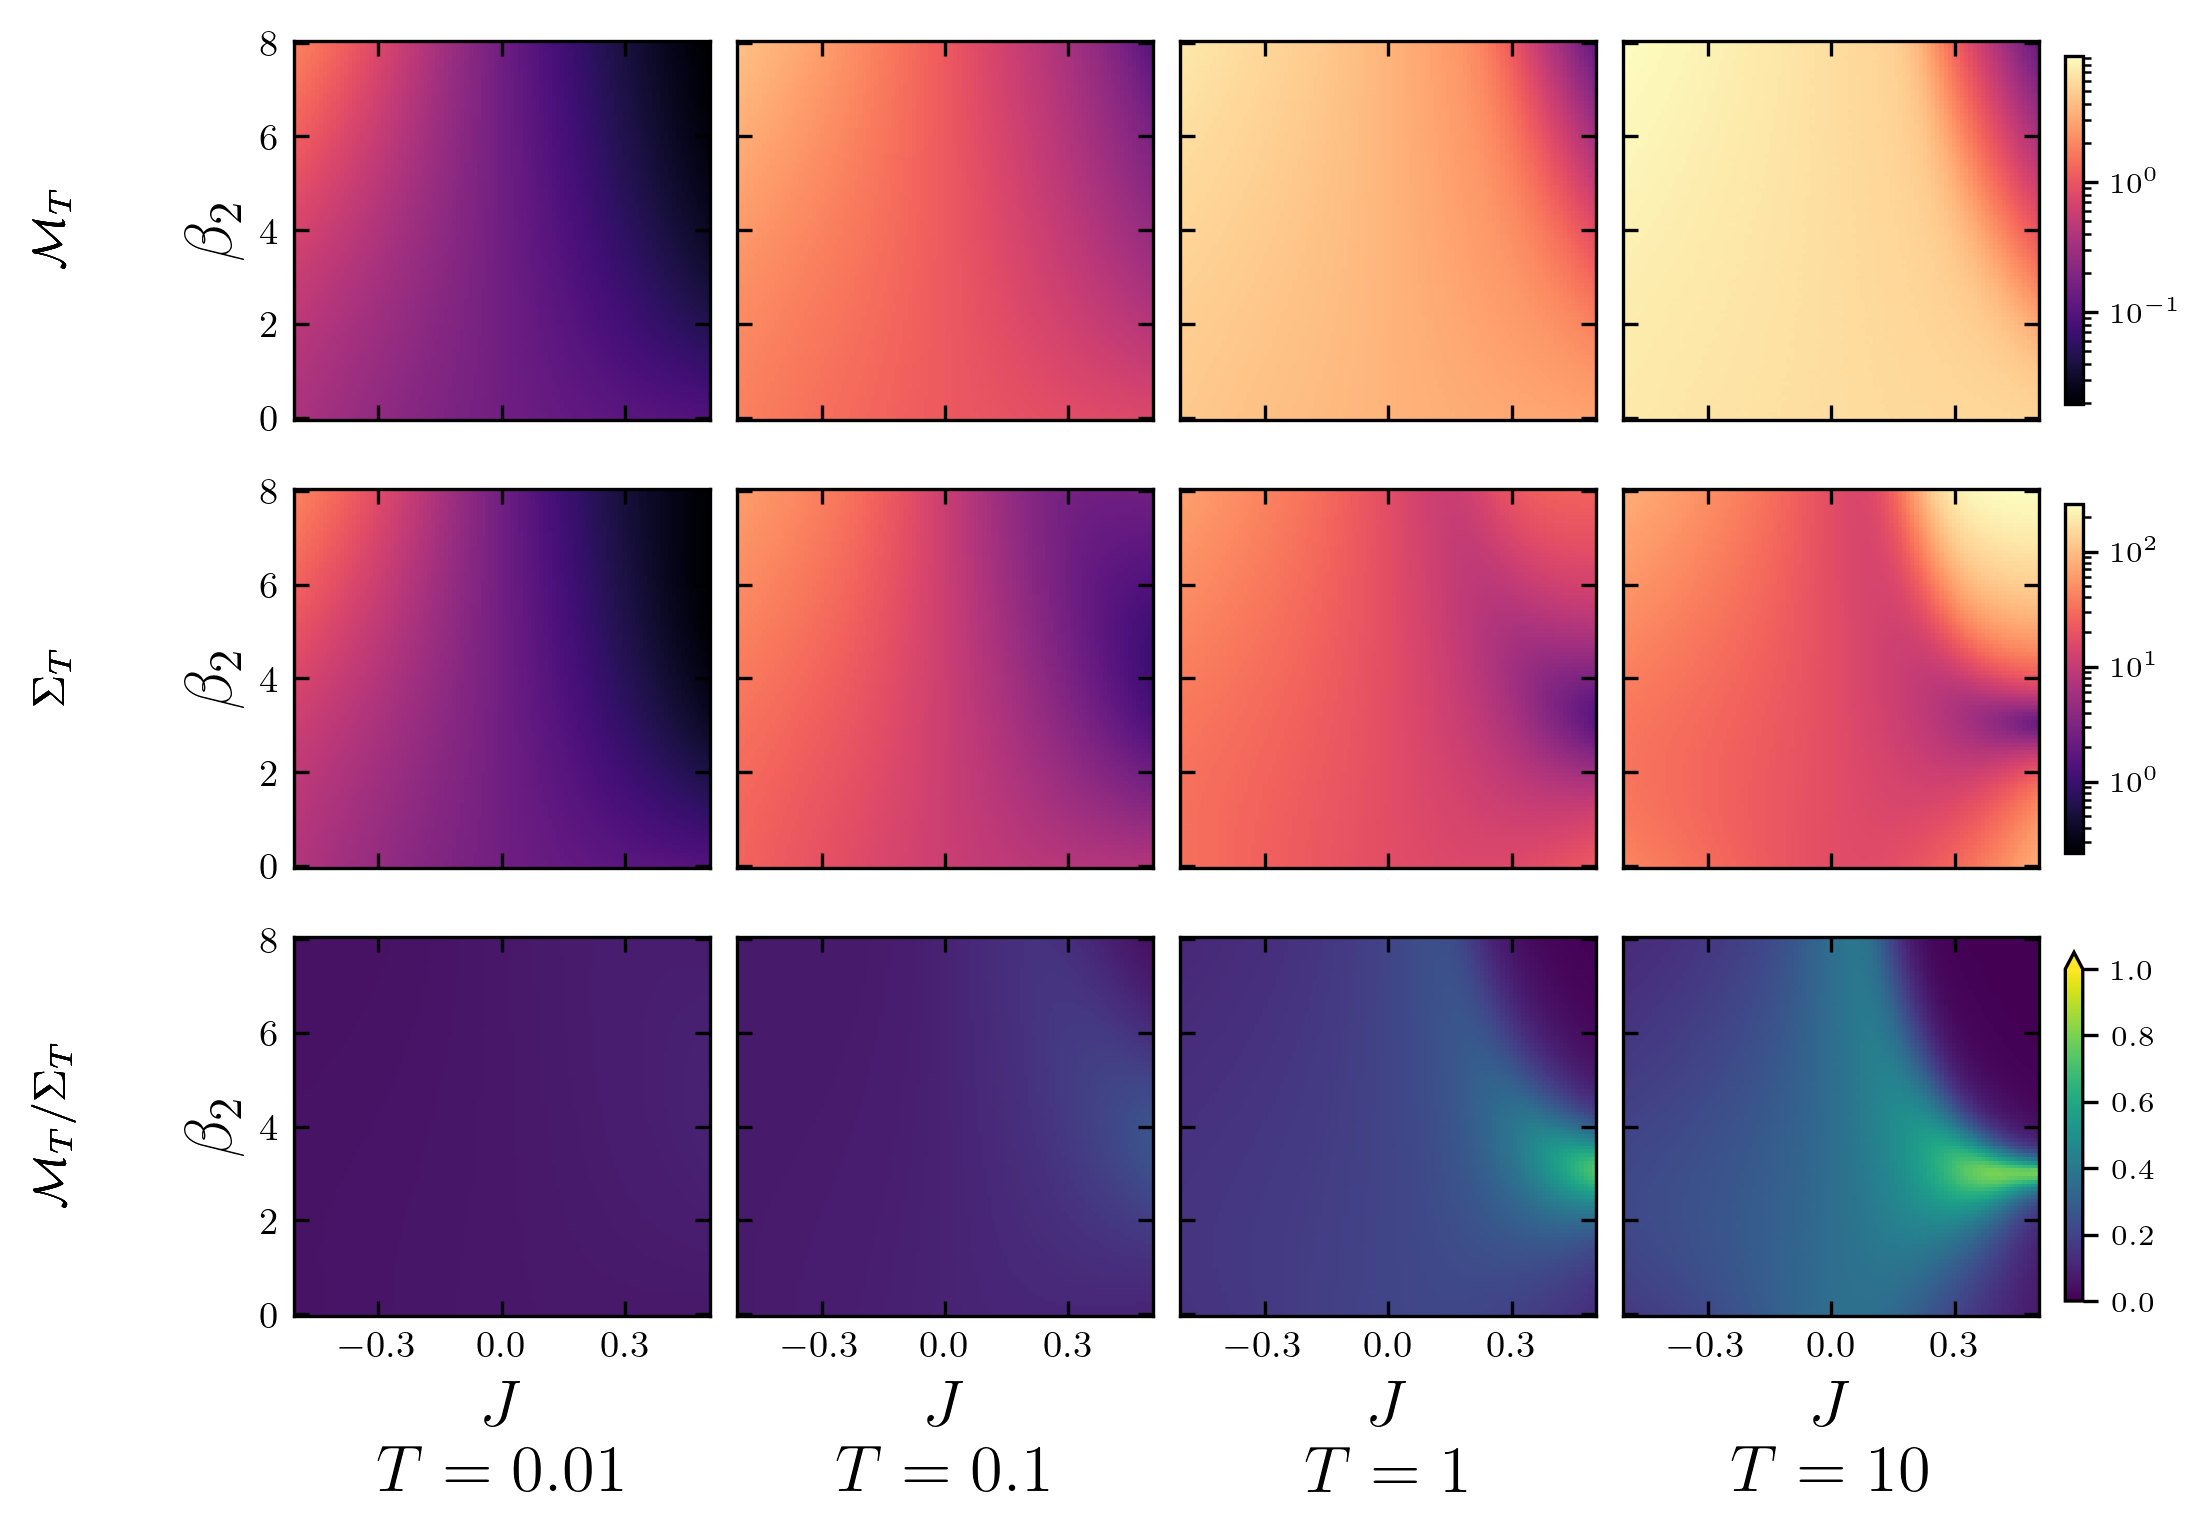

In [76]:
from matplotlib.ticker import MaxNLocator
# Approximately full width for a two-column paper.
fig, axs = plt.subplots(3, len(N_plot), 
  # figsize=(7.3, 5.8), 
  figsize=(7.3, 5.0), 
  sharex=True,
  sharey=True,
  constrained_layout=True,
  gridspec_kw={
    "wspace": 0.05,
    "hspace": 0.08,
  },
)

row_images = []
for row, (data, label, norm, cmap) in enumerate(
    zip(row_data, row_labels, row_norms, row_cmaps)
):
  im = None
  for col, physical_time in enumerate(T_values):
    ax = axs[row, col]

    im = ax.pcolormesh(
      J_grid,
      beta_grid,
      data[:, :, col],
      shading="auto",
      cmap=cmap,
      norm=norm,
      rasterized=True,
    )
    ax.xaxis.set_major_locator(MaxNLocator(4))
    ax.yaxis.set_major_locator(MaxNLocator(5))
    ax.tick_params(direction="in", top=True, right=True)

    if col == 0:
        ax.set_ylabel(r"$\beta_2$")
    else:
      ax.tick_params(labelleft=False)

    if row == len(row_data) - 1:
      ax.set_xlabel(r"$J$")

      # Column label placed below the x-axis label.
      ax.annotate(
          rf"$T={physical_time:g}$",
          xy=(0.5, -0.34),
          xycoords="axes fraction",
          ha="center",
          va="top",
          annotation_clip=False,
      )
    else:
      ax.tick_params(labelbottom=False)

    # Observable label on the far-left side of each row.
    axs[row, 0].annotate(
        label,
        xy=(-0.58, 0.5),
        xycoords="axes fraction",
        ha="center",
        va="center",
        rotation=90,
        fontsize=11,
        annotation_clip=False,
    )

  # One colorbar per observable rather than one per panel.
  cbar = fig.colorbar(
    im,
    ax=axs[row, :],
    location="right",
    pad=0.015,
    shrink=0.92,
    extend="max" if row == 2 else "neither",
  )
  cbar.ax.tick_params(labelsize=7)

plt.show()



# for col, (n, idx) in enumerate(zip(np.asarray(N_plot), N_idx)):
#   im = add_heatmap(axs[0, col], pmmc_cube[:, :, col], extent, cmap="magma")
#   axs[0, col].set_title(rf"$\mathcal{{M}}_{{{n}}}$")
#   axs[0, col].set(xlabel=r"$J$", ylabel=r"$\beta_2$")
#   fig.colorbar(im, ax=axs[0, col], label=r"$\mathcal{MC}_N$")

#   im = add_heatmap(axs[1, col], ep_cube[:, :, col], extent, cmap="magma")
#   axs[1, col].set_title(rf"$\Sigma_{{{n}}}$")
#   axs[1, col].set(xlabel=r"$J$", ylabel=r"$\beta_2$")
#   fig.colorbar(im, ax=axs[1, col], label=r"$\mathcal{MC}_N$")

#   im = add_heatmap(axs[2, col], ratio_cube[:, :, col], extent, cmap="viridis")
#   axs[2, col].set_title(rf"$\mathcal{{M}}_{{{n}}}/\Sigma_{{{n}}}$")
#   axs[2, col].set(xlabel=r"$J$", ylabel=r"$\beta_2$")
#   fig.colorbar(im, ax=axs[2, col], label=r"$\mathcal{MC}_N$")

In [55]:
fig.savefig(
    f"media/mean_field_continuous_time_heatmaps_{N}_{N_max}.pdf",
    bbox_inches="tight",
)

fig.savefig(
    f"media/mean_field_continuous_time_heatmaps_{N}_{N_max}.png",
    dpi=600,
    bbox_inches="tight",
)

In [6]:
# Parameter ranges
h_vals = jnp.linspace(0, 4, 100)
J_vals = jnp.linspace(0.1, 1.0, 20)
beta_vals = jnp.linspace(0, 8, 100)
# BB, HH = jnp.meshgrid(beta_vals, h_vals, indexing="ij")
# params = jnp.stack([BB.ravel(), HH.ravel()], axis=1)
# Number of steps to include in the cumulative MMC
# N_plot = jnp.array([1, 2, 5, 10])
N_plot = jnp.array([10, 100, 1_000, 10_000])
N_max = int(N_plot.max())
N_idx = np.asarray(N_plot - 1)


beta1 = 1.0 / T1

# extent = [h_vals[0], h_vals[-1], beta_vals[0], beta_vals[-1]]
# extent = [1, N_max + 1, beta_vals[0], beta_vals[-1]]
extent = [float(J_vals[0]), float(J_vals[-1]), float(beta_vals[0]), float(beta_vals[-1])]

mmaxes = []
# lams = np.empty((len(J_vals), len(beta_vals)), dtype=np.float32)
for j, J in enumerate(np.asarray(J_vals)):
  for i, beta_2 in enumerate(np.asarray(beta_vals)):
    _betas_nu = np.array([beta1, beta_2], dtype=np.float32)
    mmaxes.append(get_mmax(graph, _betas_nu, gammas_nu, J, h, dt, N_max))

mmax_idx = np.argmax(np.array(mmaxes))
J_idx, beta_idx = divmod(mmax_idx, len(J_vals))
lam, w, d = get_unif_stuff(graph, _betas_nu, gammas_nu, J, h, dt, N_max)



In [18]:
print(np.asarray(mmaxes).reshape(len(J_vals), len(beta_vals)))

[[ 5  5  5 ...  5  5  5]
 [ 5  5  5 ...  5  5  5]
 [ 5  5  5 ...  5  5  5]
 ...
 [ 5  5  5 ... 12 12 12]
 [ 5  5  5 ... 13 13 14]
 [ 5  5  5 ... 14 15 15]]


In [ ]:
sweep_one = make_sweep_curves_one_J(graph, lam, w, d, gammas_nu, h, dt)


# shapes: (n_beta, n_J, N_max)
pmmc_cube = np.empty((len(beta_vals), len(J_vals), len(N_plot)), dtype=np.float32)
ep_cube   = np.empty((len(beta_vals), len(J_vals), len(N_plot)), dtype=np.float32)


for j, J in enumerate(np.asarray(J_vals)):
  pmmc_beta, ep_beta = sweep_one(J, beta_vals, N_max)
  pmmc_cube[:, j, :] = np.asarray(pmmc_beta)[:, N_idx]
  ep_cube[:, j, :]   = np.asarray(ep_beta)[:, N_idx]

ratio_cube = pmmc_cube / ep_cube

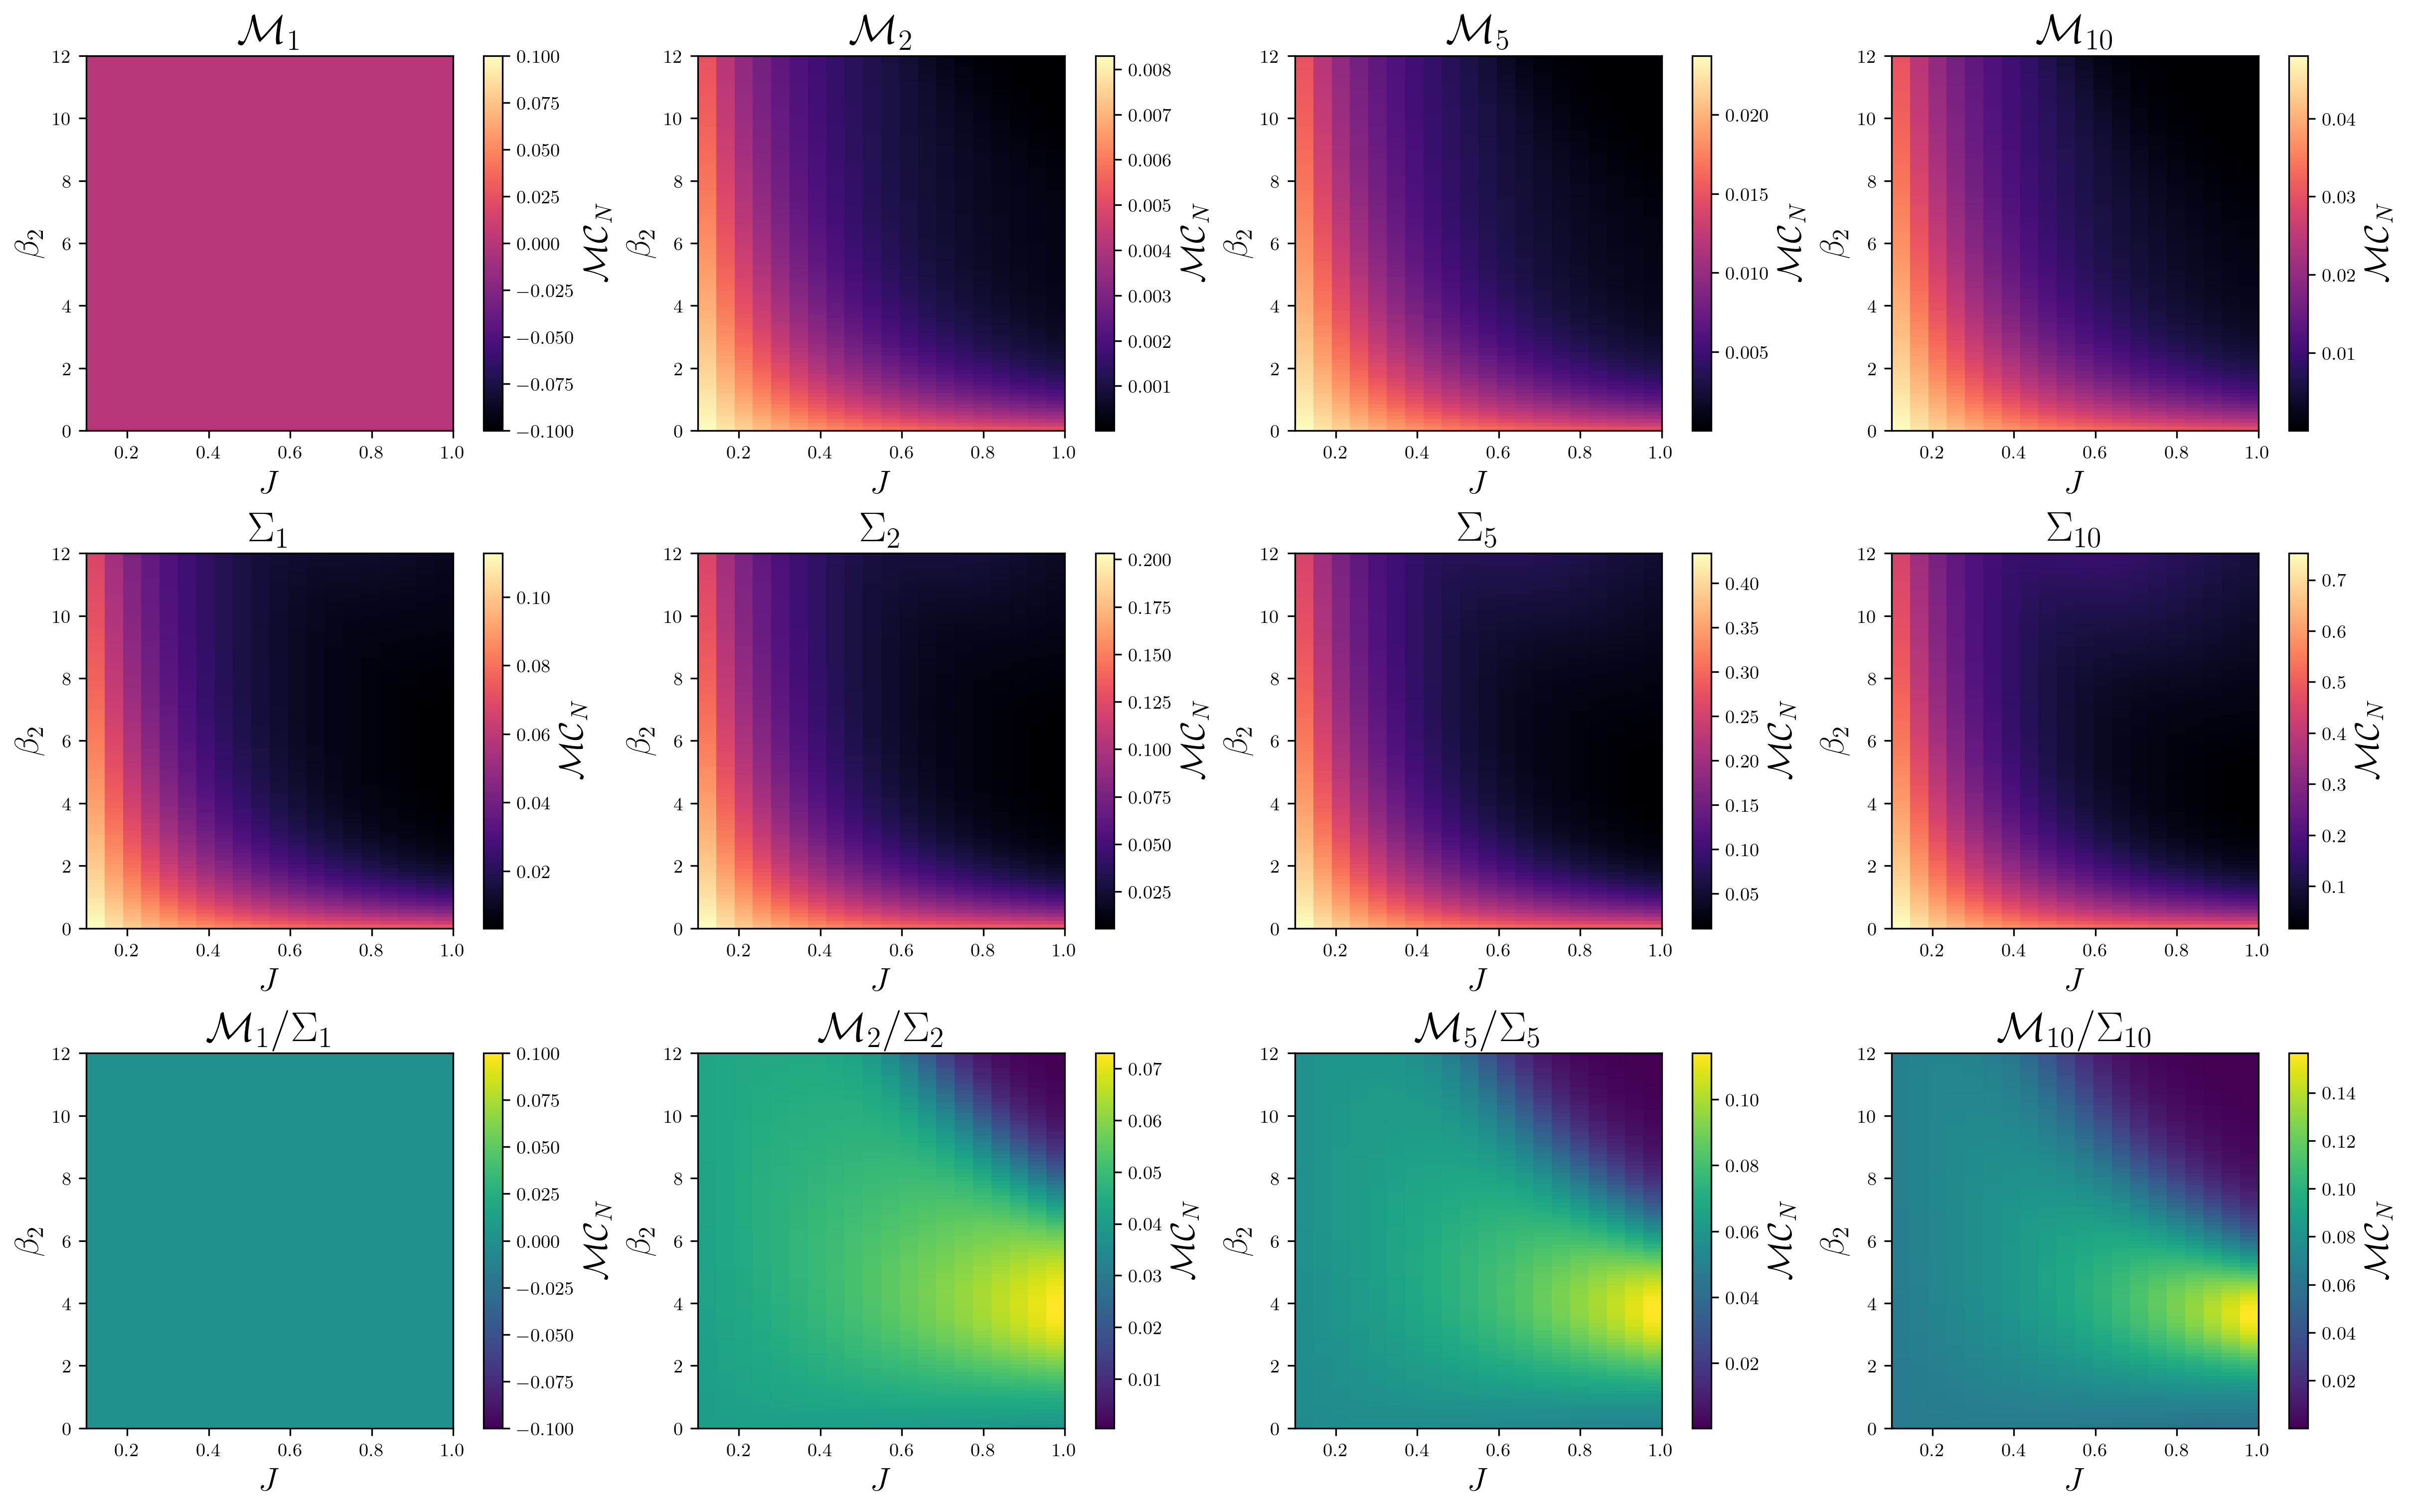

In [52]:
fig, axs = plt.subplots(3, len(N_plot), figsize=(4 * len(N_plot), 10), constrained_layout=True)

for col, (n, idx) in enumerate(zip(np.asarray(N_plot), N_idx)):
  im = add_heatmap(axs[0, col], pmmc_cube[:, :, col], extent, cmap="magma")
  axs[0, col].set_title(rf"$\mathcal{{M}}_{{{n}}}$")
  axs[0, col].set(xlabel=r"$J$", ylabel=r"$\beta_2$")
  fig.colorbar(im, ax=axs[0, col], label=r"$\mathcal{MC}_N$")

  im = add_heatmap(axs[1, col], ep_cube[:, :, col], extent, cmap="magma")
  axs[1, col].set_title(rf"$\Sigma_{{{n}}}$")
  axs[1, col].set(xlabel=r"$J$", ylabel=r"$\beta_2$")
  fig.colorbar(im, ax=axs[1, col], label=r"$\mathcal{MC}_N$")

  im = add_heatmap(axs[2, col], ratio_cube[:, :, col], extent, cmap="viridis")
  axs[2, col].set_title(rf"$\mathcal{{M}}_{{{n}}}/\Sigma_{{{n}}}$")
  axs[2, col].set(xlabel=r"$J$", ylabel=r"$\beta_2$")
  fig.colorbar(im, ax=axs[2, col], label=r"$\mathcal{MC}_N$")

In [ ]:
@partial(jax.jit, static_argnames=("N_max",))
def curves_for_params2(beta_2, J, N_max):
  Ns = jnp.arange(1, N_max + 1)
  _betas_nu = jnp.array([beta1, beta_2], dtype=jnp.float32)

  K, g = build_system_from_graph(graph, J, h, _betas_nu, gammas_nu)
  G = expm(K * dt)

  _, pts = get_traj(G, p0, N_max)

  p_avgs = jnp.cumsum(pts[:-1], axis=0) / Ns[:, None]
  Gp_avgs = p_avgs @ G.T
  entropy_diffs = H(pts[1:], axis=1) - H(p0)

  pmmcs = entropy_diffs + Ns * (H(p_avgs, axis=1) - H(Gp_avgs, axis=1))

  c_1step = precompute_ep_jax(K, g, _betas_nu, dt)
  total_eps = entropy_diffs - Ns * (p_avgs @ c_1step)

  return pmmcs, total_eps

@partial(jax.jit, static_argnames=("N_max",))
def sweep_one_J2(J, beta_vals, N_max):
  return lax.map(lambda beta2: curves_for_params2(beta2, J, N_max), beta_vals)

# shapes: (n_beta, n_J, N_max)
pmmc_cube = np.empty((len(beta_vals), len(J_vals), N_max), dtype=np.float32)
ep_cube   = np.empty((len(beta_vals), len(J_vals), N_max), dtype=np.float32)

for j, J in enumerate(np.asarray(J_vals)):
  pmmc_beta, ep_beta = sweep_one_J2(J, beta_vals, N_max)
  pmmc_cube[:, j, :] = np.asarray(pmmc_beta)
  ep_cube[:, j, :]   = np.asarray(ep_beta)

ratio_cube = pmmc_cube / ep_cube

fig, axs = plt.subplots(3, len(N_plot), figsize=(4 * len(N_plot), 10), constrained_layout=True)

for col, (n, idx) in enumerate(zip(np.asarray(N_plot), N_idx)):
  im = add_heatmap(axs[0, col], pmmc_cube[:, :, idx], extent, cmap="magma")
  axs[0, col].set_title(rf"$\mathcal{{M}}_{{{n}}}$")
  axs[0, col].set(xlabel=r"$J$", ylabel=r"$\beta_2$")
  fig.colorbar(im, ax=axs[0, col], label=r"$\mathcal{MC}_N$")

  im = add_heatmap(axs[1, col], ep_cube[:, :, idx], extent, cmap="magma")
  axs[1, col].set_title(rf"$\Sigma_{{{n}}}$")
  axs[1, col].set(xlabel=r"$J$", ylabel=r"$\beta_2$")
  fig.colorbar(im, ax=axs[1, col], label=r"$\mathcal{MC}_N$")

  im = add_heatmap(axs[2, col], ratio_cube[:, :, idx], extent, cmap="viridis")
  axs[2, col].set_title(rf"$\mathcal{{M}}_{{{n}}}/\Sigma_{{{n}}}$")
  axs[2, col].set(xlabel=r"$J$", ylabel=r"$\beta_2$")
  fig.colorbar(im, ax=axs[2, col], label=r"$\mathcal{MC}_N$")

In [ ]:
lam = float(N * gammas_nu.sum().item())
a_coeff, b_coeff, avg_tail, final_tail = make_uniformization_coeffs(lam, dt, N_max, tol=1e-12,)
print(len(a_coeff), avg_tail, final_tail)

def pmmc_eval(betas, N):
  return pmmc_kernel_fast(
    p0, graph, J, h, betas, gammas_nu, N, lam, a_coeff, b_coeff,
  )

@jax.jit
def pmmc_row(betas, Ns):
  return lax.map(lambda h: pmmc_eval(betas, h), Ns)


@jax.jit
def eval_heatmap(params):
  def one(x):
    beta, N = x
    return pmmc_eval(jnp.array([beta, beta]), N)
  
  return lax.map(one, params, batch_size=4)


# _ = pmmc_eval(jnp.array([beta_vals[0], beta_vals[0]]), h_vals[0]).block_until_ready()  # one compile

rows, dE_J, dE_h_sign = graph


heatmap = np.empty((len(beta_vals), len(J_vals)), dtype=np.float32)
heatmap2 = np.empty((len(beta_vals), len(J_vals)), dtype=np.float32)
# heatmap2 = np.empty((len(beta_vals), len(h_vals)), dtype=np.float32)
for i, beta in enumerate(beta_vals):
  # heatmap[i] = np.asarray(pmmc_row(jnp.array([beta1, beta]), h_vals))
  betas_nu_i = jnp.array([beta1, beta])
  K, g = build_system_from_graph(graph, J, h, betas_nu_i, gammas_nu)

  # ── Propagator and time evolution ─────────────
  G_β  = jnp.array(expm(K * dt))
  EM_dt, A_1step = precompute_ep(K, g, dt)
  c_1step = betas_nu_i @ A_1step
  n_baths, ns = g.shape
  # Computing the SLT
  # escape rates vector
  lam = -np.diag(K)           # lambda(sigma) = -K(sigma|sigma)

  # block matrix for activity integral
  # same structure as EP precomputation but with lam instead of g
  M_act = np.zeros((ns + 1, ns + 1))
  M_act[:ns, :ns] = K.T
  M_act[:ns, ns]  = lam       # single vector, not two baths
  EM_act_dt = expm(M_act * dt)

  pN, pts = get_traj(G_β, p0, N_max)
  p_avgs = jnp.cumsum(pts[:-1], axis=0) / Ns[:, None]                  # broadcasting
  Gp_avgs = p_avgs @ G_β.T                         # G @ p_avg for each N

  # H(G^N p0) - H(p0) + N*(H(p_avg) - H(G p_avg))
  # vectorized over rows
  entropy_diffs = H(pts[1:], axis=1) - H(p0)
  pmmcs = entropy_diffs + Ns * (H(p_avgs, axis=1) - H(Gp_avgs, axis=1))
  heatmap[i] = np.asarray(pmmcs)

  # stationary state — null eigenvector of K
  # print(g[0] @ pi, g[1] @ pi, (g[0] + g[1]) @ pi)
  # print(jnp.sum((g[0] @ pts.T) * dt) + jnp.sum((g[1] @ pts.T) * dt))
  # total_eps = entropy_diffs - Ns * (p_avgs @ c_1step)

  EM_n     = np.eye(n_states + 2)
  heats = jnp.zeros(N_max)
  for n in range(N_max):
    EM_n        = EM_n @ EM_dt
    A_n         = EM_n[:n_states, n_states:].T              # (2, ns)
    c_n         = np.array(betas_nu_i) @ A_n               # (ns,)
    heats = heats.at[n].add(- c_n @ p0)

  total_eps = heats + entropy_diffs

  heatmap2[i] = np.asarray(total_eps)



In [ ]:
cmap = 'magma'
fig, _axs = plt.subplots(2, 3, figsize=(20,12), squeeze=False)
axs: list[Axes] = _axs.flatten().tolist()
delta = np.asarray(heatmap / heatmap2)
im = add_heatmap(axs[0], heatmap, extent, cmap=cmap)
axs[0].set(xlabel=r"$N$", ylabel=r"$\beta$", title=fr"MMC multi-reservoir; $\beta_1={beta1}$", xscale='log')
# axs[1].scatter(idxs, beta_vals, color='white')
fig.colorbar(im, ax=axs[0], label=r"$\mathcal{MC}_N$")

im = add_heatmap(axs[1], heatmap2, extent, cmap=cmap)
axs[1].set(xlabel=r"$N$", ylabel=r"$\beta$", title=r"Total EP at $\bar{q}$", xscale='log')
fig.colorbar(im, ax=axs[1], label=r"EP")

im = axs[2].imshow(delta, origin='lower', extent=extent, aspect='auto', cmap='seismic')
axs[2].set(xlabel=r"$h$", ylabel=r"$\beta$", title=r"Residual cost")
fig.colorbar(im, ax=axs[2], label=r"$\sum_\nu Q^\nu(q)\beta_\nu$")
fig.suptitle(fr"Minimal Periodic MMC for $|\Lambda|={N}$, $dt={dt:.4f}$, $h={h}$, $J={J}$")
plt.tight_layout()
plt.show()
# fig.savefig(f"media/discrete_vs_continuous_N{Nsteps}_Lam{N}.pdf")


In [ ]:


# for i, beta in enumerate(beta_vals):
#   # heatmap2[i] = np.asarray(pmmc_row(jnp.array([beta, beta]), h_vals))
#   rates_nu = ising.get_rates(graph, J, h, jnp.array([beta, beta]), gammas_nu)
#   rates = rates_nu.sum(0)
#   dE = J * dE_J + h * dE_h_sign
#   g = ising.heat_rate_vectors(rates_nu, dE)
#   K = ising.dense_generator_from_rates(graph[0], rates)

#   # ── Propagator and time evolution ─────────────
#   G_β  = jnp.array(expm(K * dt))
#   pN, pts = get_traj(G_β, p0, N_max)
#   p_avgs = jnp.cumsum(pts[:-1], axis=0) / Ns[:, None]                  # broadcasting

#   Gp_avgs = p_avgs @ G_β.T                         # G @ p_avg for each N

#   # H(G^N p0) - H(p0) + N*(H(p_avg) - H(G p_avg))
#   # vectorized over rows
#   pmmcs = (
#     H(pts[1:], axis=1) - H(p0) + Ns * (H(p_avgs, axis=1) - H(Gp_avgs, axis=1))
#   )
#   heatmap2[i] = np.asarray(pmmcs)



# heatmap2 = np.asarray(eval_heatmap(params)).reshape(len(beta_vals), len(h_vals))

# def pmmc_eval(beta, h):
#   return pmmc_kernel_old(p0, graph, beta, h, J, Nsteps)

# @jax.jit
# def pmmc_row(beta, h_vals):
#   return lax.map(lambda h: pmmc_eval(beta, h), h_vals)

# # _ = pmmc_eval(beta_vals[0], h_vals[0]).block_until_ready()  # one compile

# heatmap2 = np.empty((len(beta_vals), len(h_vals)), dtype=np.float32)
# for i, beta in enumerate(beta_vals):
#   heatmap2[i] = np.asarray(pmmc_row(beta, h_vals))

In [ ]:
cmap = 'magma'
fig, _axs = plt.subplots(2, 3, figsize=(20,12), squeeze=False)
axs: list[Axes] = _axs.flatten().tolist()
delta = np.asarray(heatmap/heatmap2)
# delta_absmax = float(np.max(np.abs(delta)))
# delta_norm = mcolors.TwoSlopeNorm(
#   vmin=-(delta_absmax if delta_absmax > 0.0 else 1.0),
#   vcenter=0.0,
#   vmax=(delta_absmax if delta_absmax > 0.0 else 1.0),
# )
im = add_heatmap(axs[0], heatmap, extent, cmap=cmap)
axs[0].set(xlabel=r"$N$", ylabel=r"$\beta$", title=fr"MMC multi-reservoir; $\beta_1={beta1}$", xscale='log')
# axs[1].scatter(idxs, beta_vals, color='white')
fig.colorbar(im, ax=axs[0], label=r"$\mathcal{MC}_N$")

im = add_heatmap(axs[1], heatmap2, extent, cmap=cmap)
axs[1].set(xlabel=r"$N$", ylabel=r"$\beta$", title=r"Total EP at $\bar{q}$", xscale='log')
fig.colorbar(im, ax=axs[1], label=r"EP")

im = axs[2].imshow(
  delta,
  origin='lower',
  extent=extent,
  aspect='auto',
  cmap='seismic',
  # norm=delta_norm,
)
axs[2].set(xlabel=r"$h$", ylabel=r"$\beta$", title=r"Residual cost")
fig.colorbar(im, ax=axs[2], label=r"$\sum_\nu Q^\nu(q)\beta_\nu$")
fig.suptitle(fr"Minimal Periodic MMC for $|\Lambda|={N}$, $dt={dt:.4f}$, $h={h}$, $J={J}$")
plt.tight_layout()
plt.show()
# fig.savefig(f"media/discrete_vs_continuous_N{Nsteps}_Lam{N}.pdf")


In [ ]:
compare_heatmaps(heatmap, heatmap2, Nsteps, N, dt, h, J, beta1, extent, cmap='magma')

In [ ]:
λ = K.sum(axis=1) + np.diag(K)

def escape_rate(i):
  return λ[i]

# τ ~ exp(λ(σ))

print(np.std(np.exp(λ)))

In [ ]:
rates = ising.get_rates(graph, J, h, betas_nu, gammas_nu).sum(0)
K = ising.dense_generator_from_rates(graph[0], rates)
# ── Propagator and time evolution ─────────────

# start from all-spins-up
# p0 = np.zeros(n_states)
# p0[state_idx[tuple(np.ones(N, dtype=np.int8))]] = 1.0

# t  = 0.0001
t = 1e-3
pt = expm(K * t) @ p0
plt.bar(range(n_states), pt, color='red', alpha=0.5)

pt, mass = ising.propagate_ctmc(p0, t, graph, J, h, betas_nu, gammas_nu)
plt.bar(range(n_states), pt, color='blue', alpha=0.5)
plt.show()


# ---- test params
β = jnp.array([1.0])
γ = jnp.array([1.0])
dt = 1 / N

actual = ising.apply_glauber_transition(p0, graph, β, h, J)
rates = ising.get_rates(graph, J, h, β, γ)
Kp = ising.apply_K_from_rates(p0, graph[0], rates[0])
p_from_K = p0 + Kp / N


def relerr(a, b):
  return jnp.linalg.norm(a - b) / jnp.linalg.norm(b)

print(f"rel err={relerr(p_from_K, actual)}")


# uniform lambdas should be ~ N = L^2
res, aux = ising.propagate_ctmc(p0, dt, graph, J, h, β, γ)
print(f"rel err={relerr(res, actual)},\tλ={aux['lam']}")

res, aux = ising.propagate_ctmc(p0, dt, graph, J, h, β, γ, use_glauber=True)
print(f"rel err={relerr(res, actual)},\tλ={aux['lam']}")

# for t in jnp.linspace(0, 0.05, 100):
#   test = propagate_ctmc(p0, t, graph, J, h, jnp.array([1.0, 1.0]), jnp.array([1.0, 1.0]),)
#   print(f"t={float(t)}\n {jnp.linalg.norm(test[0]-actual)/jnp.linalg.norm(actual)}")
#   print()


In [ ]:
# ── Parameters ──────────────────────────────
dt = 0.001
N_max = 10000
Ns     = jnp.arange(1, N_max + 1)
Ts = np.linspace(0, 2, 49)[1:]


fig, _axs = plt.subplots(1, 4, figsize=(24, 6), squeeze=False, constrained_layout=True)
axs: list[Axes] = _axs.flatten().tolist()
norm = mcolors.Normalize(vmin=Ts.min(), vmax=Ts.max())
cmap = mpl.colormaps["viridis"]
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

# for T in (*range(1, 9), 100):
for T in Ts:
  print(f"β={1/T}")
  color = cmap(norm(T))
  betas_this = jnp.array([1/T1, 1/T])
  rates_nu = ising.get_rates(graph, J, h, betas_this, gammas_nu)
  rates = rates_nu.sum(0)
  rows, dE_J, dE_h_sign = graph
  dE = J * dE_J + h * dE_h_sign
  g = ising.heat_rate_vectors(rates_nu, dE)
  K = ising.dense_generator_from_rates(graph[0], rates)

  # ── Propagator and time evolution ─────────────
  G  = jnp.array(expm(K * dt))

  # p <- G @ p
  # precompute all p_t = G^t @ p0 as a matrix — one pass
  pN, pts = get_traj(G, p0, N_max)

  # cumulative average: p_avg(N) = (1/N) Σ_{t=0}^{N-1} p_t
  # shape (N_max, n_states)
  p_avgs = jnp.cumsum(pts[:-1], axis=0) / Ns[:, None]                  # broadcasting

  Gp_avgs = p_avgs @ G.T                         # G @ p_avg for each N

  # H(G^N p0) - H(p0) + N*(H(p_avg) - H(G p_avg))
  # vectorized over rows
  pmmcs = (
    H(pts[1:], axis=1) - H(p0) + Ns * (H(p_avgs, axis=1) - H(Gp_avgs, axis=1))
  )

  # stationary state — null eigenvector of K
  vals, vecs = np.linalg.eig(K)
  idx = np.argmin(np.abs(vals)) # closest to 0
  pi  = np.real(vecs[:, idx])
  pi  = np.clip(pi / pi.sum(), 0, None)
  print(g[0] @ pi, g[1] @ pi, (g[0] + g[1]) @ pi)
  print(jnp.sum((g[0] @ pts.T) * dt) + jnp.sum((g[1] @ pts.T) * dt))
  kl  = KL(p0, pi)     # KL(p0 || pi) = Σ p log(p/q)
  # G, rhs = make_precomp_rhs(K, dt, g)
  # a1, a2 = precomp_ep_cost(p0, rhs, dt)
  # c = betas_nu[0] * a1 + betas_nu[1] * a2
  # Sigma = EP_cost(p0, G, c)
  # plt.hlines(y=Sigma, xmin = 0, xmax = Ns[-1], color = 'red', linestyles='dashed')
  _, a_nu = precompute_ep(G, g, dt)[1]
  c = betas_this @ a_nu
  
  total_eps = H(pts[1:], axis=1) - H(p0) - Ns * (p_avgs @ c)

  nonadiabatic_eps = kl - KL(pts[1:], pi, axis=1)
  housekeeping_eps = total_eps - nonadiabatic_eps

  q_phys, residual_step, info = find_optimal_prior(G, c)
  print("residual EP =", residual_step)
  Gq = G @ q_phys

  mc_step = KL(pts[:-1], q_phys, axis=1) - KL(pts[1:], Gq, axis=1)
  mc_phys = jnp.cumsum(mc_step)
  residual_phys = Ns * residual_step
  total_eps_phys = mc_phys + residual_phys

  print(f"Max diff in EP vs EP phys q = {jnp.max(jnp.abs(total_eps - total_eps_phys))}")

  # color = line.__dict__['_color']
  axs[0].semilogx(Ns, pmmcs, color=color, lw=1.8)
  axs[1].semilogx(Ns, total_eps, color=color, lw=1.8)
  axs[2].semilogx(Ns, mc_phys, color=color, lw=1.8)
  axs[3].semilogx(Ns, total_eps_phys - total_eps, color=color, lw=1.8)

  
  kl_q = KL(p0, q_phys)
  # axs[1].hlines(y=kl_q, xmin=0, xmax=Ns[-1], color=color, linestyles=':', alpha=0.5)

  axs[0].hlines(y=kl, xmin=0, xmax=Ns[-1], color=color, linestyles='--', alpha=0.5)
  axs[1].hlines(y=kl, xmin=0, xmax=Ns[-1], color=color, linestyles='--', alpha=0.5)

  print(f"rel err q_phys, pi = {jnp.linalg.norm(q_phys - pi) / jnp.linalg.norm(q_phys)}")
  print()

axs[0].set(xlabel=r"$N$ iterations", ylabel=r"$\mathcal{MC}_N$")
axs[0].set_title(f"Total EP vs iterations")

axs[1].set(xlabel=r"$N$ iterations", ylabel=r"$\Sigma_{dt}$")
axs[1].set_title(f"MMC vs iterations")
# axs[1].set_yscale('log')

axs[2].set(xlabel=r"$N$ iterations", ylabel=r"MMC(q_phys)")
axs[2].set_title(f"MMC(q_phys) vs iterations")
axs[2].set_yscale('log')

axs[3].set_yscale('log')

cbar = fig.colorbar(sm, ax=axs, location="right", pad=0.02, shrink=0.95)
cbar.set_label(r"$T_2$")
fig.suptitle(f"Entropic quantities vs iterations (dt={dt}, T1={T1}, T2 varied)")
# plt.tight_layout()
fig.savefig(f"media/MMC_vs_total_EP.pdf")

$$
\dot Q_\nu(\sigma) = \sum_i k_i^\nu(\sigma)\Delta E_i(\sigma)
$$

In [ ]:
rates_nu, rates, dE = ising.get_rates(
  graph, J, h, betas_nu, gammas_nu
)

# (n_baths, n_states)
g = ising.heat_rate_vectors(rates_nu, dE)

# Qdot = g @ p

In [ ]:
tau = 1.0

p0 = np.ones(n_states) / n_states

rhs = make_rhs(K, g)
Sigma, p_tau, Q1, Q2 = total_ep(
    p0, rhs, tau, betas_nu
)

print("Q1 =", Q1)
print("Q2 =", Q2)
print("Total EP =", Sigma)


G, rhs = make_precomp_rhs(K, tau, g)
a1, a2 = precomp_ep_cost(p0, rhs, tau)
c = betas_nu[0] * a1 + betas_nu[1] * a2
Sigma = ising.EP_cost(p0, G, c)
print(Sigma)


In [ ]:
from scipy.special import softmax
# if T1=T2
# pi = softmax(-betas_nu[0] * energies)

q_star, residual_EP, info = find_optimal_prior(G, c)
total_EP = ising.EP_cost(p0, G, c)
MC_from_EP = total_EP - residual_EP

p_tau = G @ p0
q_tau = G @ q_star
MC_from_KL = KL(p0, q_star) - KL(p_tau, q_tau)

print("residual EP =", residual_EP)
print("KKT residual =", info["kkt_residual"])
print("iterations =", info["iterations"])

print("Total EP =", total_EP)
print("MC from EP difference =", MC_from_EP)
print("MC from KL contraction =", MC_from_KL)
print("difference =", MC_from_EP - MC_from_KL)

# stationary state — null eigenvector of K
vals, vecs = np.linalg.eig(G)
idx = np.argmin(np.abs(vals - 1.0))    # eigenvalue closest to 1, not 0
pi  = np.real(vecs[:, idx])
pi  = np.clip(pi / pi.sum(), 0, None)

gibbs_EP = ising.EP_cost(pi, G, c)

print("stationarity:", np.linalg.norm(K @ pi))
print("EP at Gibbs:", gibbs_EP)


pi_tau = G @ pi

MC_from_EP = total_EP - gibbs_EP

MC_from_KL = KL(p0, pi) - KL(p_tau, pi_tau)

print("MC from EP difference =", MC_from_EP)
print("MC from KL contraction =", MC_from_KL)
print("difference =", MC_from_EP - MC_from_KL)

